In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("C:/Users/zinan/OneDrive/Documents/spam email.csv")
df

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/zinan/OneDrive/Documents/spam email.csv'

In [ ]:
df.shape

(83448, 2)

In [ ]:
df.columns

Index(['label', 'text'], dtype='object')

In [ ]:
df.ndim

2

In [ ]:
df.describe()

,label
count,83448.000000
mean,0.526196
std,0.499316
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [ ]:
df.tail

<bound method NDFrame.tail of        label                                               text
0          1  ounce feather bowl hummingbird opec moment ala...
1          1  wulvob get your medircations online qnb ikud v...
2          0   computer connection from cnn com wednesday es...
3          1  university degree obtain a prosperous future m...
4          0  thanks for all your answers guys i know i shou...
...      ...                                                ...
83443      0  hi given a date how do i get the last date of ...
83444      1  now you can order software on cd or download i...
83445      1  dear valued member canadianpharmacy provides a...
83446      0  subscribe change profile contact us long term ...
83447      1  get the most out of life ! viagra has helped m...

[83448 rows x 2 columns]>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [ ]:
df.dtypes

label     int64
text     object
dtype: object

In [ ]:
df.isna().sum()

label    0
text     0
dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder
lab=LabelEncoder()
df['text']=lab.fit_transform(df['text'])
df

,label,text
0,1,58703
1,1,80788
2,0,1101
3,1,75357
4,0,69196
...,...,...
83443,0,36997
83444,1,53072
83445,1,22044
83446,0,67389


In [ ]:
df1=df['label'].value_counts()
df1

label
1    43910
0    39538
Name: count, dtype: int64

Text(0.5, 1.0, 'label_count')

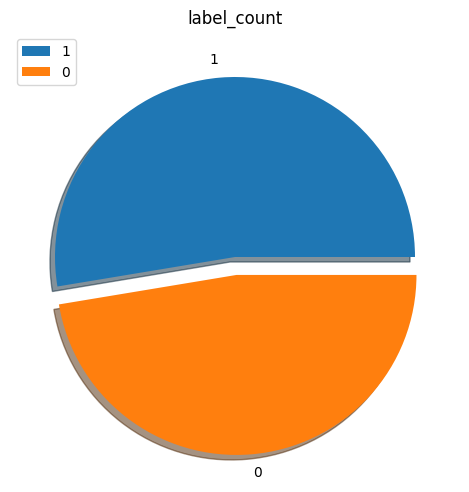

In [ ]:
ex=[0,0.1]
plt.pie(df1.values,labels=df1.index,shadow=True,explode=ex)
plt.legend(loc='upper left')
plt.tight_layout()
plt.title('label_count')

Text(22.472222222222214, 0.5, 'Values')

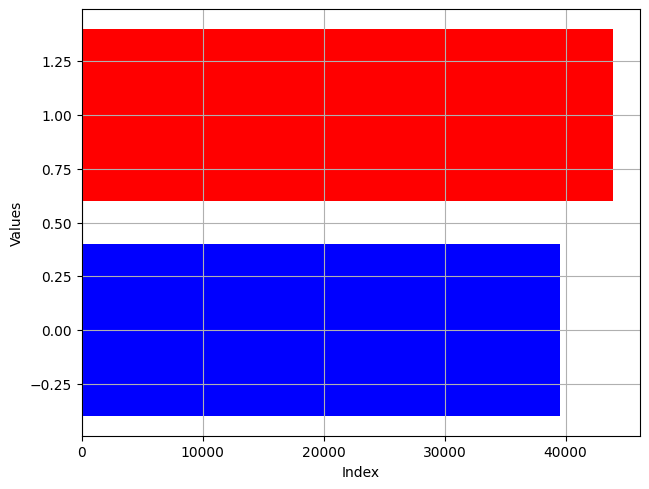

In [ ]:
co=['r','b']
plt.barh(df1.index,df1.values,color=co)
plt.grid()
plt.tight_layout()
plt.xlabel('Index')
plt.ylabel('Values')

In [ ]:
x=df.iloc[:,-1].values.reshape(-1,1)
y=df.iloc[:,:1].values
x

array([[58703],
       [80788],
       [ 1101],
       ...,
       [22044],
       [67389],
       [30480]], shape=(83448, 1))

In [ ]:
y

array([[1],
       [1],
       [0],
       ...,
       [1],
       [0],
       [1]], shape=(83448, 1))

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)
x_train

array([[41193],
       [ 9249],
       [15174],
       ...,
       [41611],
       [ 8751],
       [ 1950]], shape=(58413, 1))

In [ ]:
x_test

array([[ 7269],
       [20840],
       [32137],
       ...,
       [27938],
       [ 1686],
       [43970]], shape=(25035, 1))

In [ ]:
y_train

array([[1],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]], shape=(58413, 1))

In [ ]:
y_test

array([[0],
       [1],
       [1],
       ...,
       [0],
       [0],
       [1]], shape=(25035, 1))

In [ ]:
from sklearn.preprocessing import StandardScaler
Scalar=StandardScaler()
Scalar.fit(x_train)
x_train=Scalar.transform(x_train)
x_test=Scalar.transform(x_test)
x_train

array([[-1.69770141e-02],
       [-1.34421483e+00],
       [-1.09803764e+00],
       ...,
       [ 3.90422877e-04],
       [-1.36490618e+00],
       [-1.64748019e+00]], shape=(58413, 1))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train.flatten())
y_pred=knn.predict(x_test).reshape(-1,1)
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [1]], shape=(25035, 1))

In [ ]:
y_test

array([[0],
       [1],
       [1],
       ...,
       [0],
       [0],
       [1]], shape=(25035, 1))

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
cm=confusion_matrix(y_test,y_pred)
cm

array([[10095,  1723],
       [ 1432, 11785]])

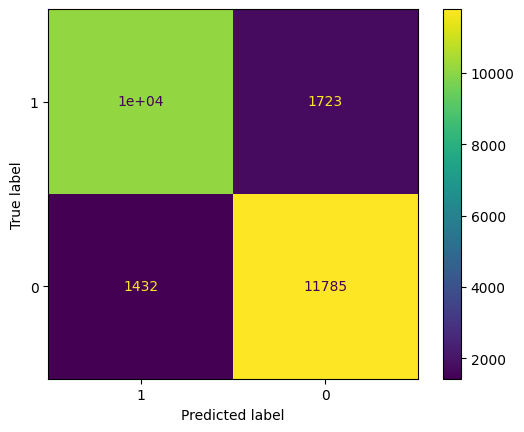

In [ ]:
lab=[1,0]
cmd=ConfusionMatrixDisplay(cm,display_labels=lab)
cmd.plot()

In [ ]:
score=accuracy_score(y_test,y_pred)*100
score

87.39764329938086

In [ ]:
from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.85      0.86     11818
           1       0.87      0.89      0.88     13217

    accuracy                           0.87     25035
   macro avg       0.87      0.87      0.87     25035
weighted avg       0.87      0.87      0.87     25035

